## Paper Summary


Zarattini, Aziz, and Barbon’s *“Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)”* (Swiss Finance Institute Research Paper Series No. 24-97) examines whether a simple intraday time-series momentum rule on SPY can generate statistically and economically significant risk-adjusted returns when entries are triggered by abnormal intraday demand/supply imbalance and exits are managed with dynamic trailing stops.
They introduce a time-of-day “Noise Area” (dynamic intraday boundaries) that defines when price action is likely equilibrium noise versus a potential trend, and they trade only when SPY breaches those boundaries.
They show that a baseline implementation is vulnerable to sharp intraday reversals (negative skew and occasional large losses), and they materially improve the payoff distribution by tightening exits via the current Noise-Area band and VWAP-based trailing stops.
They further enhance compounding and stabilize exposure by applying a volatility-targeting sizing rule (capped leverage) that produces a large, statistically significant alpha and near-zero/negative market beta in-sample.
Finally, they stress-test profitability across volatility regimes, calendar effects, common daily technical patterns, and transaction-cost assumptions to characterize when the edge is strongest and how sensitive it is to implementation frictions.
Overall, the paper’s core takeaway is that intraday time-series momentum in a highly liquid index ETF appears monetizable when (i) trend initiation is conditioned on time-varying “abnormal move” thresholds and (ii) exits and exposure are engineered to reduce reversal risk and regime dependence.

### The paper formalizes “abnormal intraday trend initiation” using a time-varying Noise Area and trades only on boundary breaks.

The strategy defines equilibrium “noise” as intraday moves that are not meaningfully larger than typical moves for the same time-of-day, using a rolling window of 1-minute SPY data (May 2007–Apr 2024) and computing, for each time $HH:MM$, the average absolute move from the open over the prior 14 days.
Formally, for each $HH:MM$ they compute $$(\sigma_{t,9:30\rightarrow HH:MM} = \frac{1}{14}\sum_{i=1}^{14}\left|\frac{Close_{t-i,HH:MM}}{Open_{t-i,9:30}}-1\right|)$$ then build boundaries around today’s open with an overnight-gap adjustment: $$(Upper_{t,HH:MM}=\max(Open_{t,9:30},Close_{t-1,16:00})(1+\sigma))$$ $$(Lower_{t,HH:MM}=\min(Open_{t,9:30},Close_{t-1,16:00})(1-\sigma))$$
If price is above the upper boundary the model goes long; if below the lower boundary it goes short; to reduce noise-triggered churn it evaluates/executes on semi-hourly timestamps (HH:00 and HH:30) and closes all positions by the cash close (16:00).
The key implementation idea is that the “required move” to call something abnormal increases through the day, so the trigger adapts to intraday volatility seasonality rather than using a fixed breakout threshold.

### A baseline trailing-stop design produces only modest performance and displays reversal fragility.

The authors first test a base model that uses the opposite side of the Noise Area as a trailing stop (e.g., for longs, stop at the lower band), sizes at 100% notional each day, and includes explicit per-share costs (commission and slippage).
In this configuration (2007–2024) they report a total return of 178%, an annualized return of 6.2%, volatility of 10.9%, and Sharpe ratio of 0.61, with a worst daily return of about −10.33% and negative skewness—features that are atypical for a well-behaved trend strategy.
They attribute the tail risk to sharp intraday reversals that occur after an early trend signal (illustrated with a Jan 20, 2022 example), where a late-day regime change forces an exit/reversal that converts an early edge into a large loss.
The practical conclusion is that “trend detection” alone is insufficient at intraday horizons; the exit logic must be explicitly designed to prevent trend-to-reversal days from dominating the left tail.

### Tightening exits with a current-band and VWAP trailing stop materially improves the payoff distribution and Sharpe ratio, at the cost of higher turnover.

To mitigate reversal losses, the paper next replaces the opposite-band trailing stop with a tighter stop tied to the “current band” and then further refines it by incorporating VWAP as a dynamic exit signal, closing positions when price crosses either the relevant band or VWAP (for longs: $(TrailingStop=\max(UpperBand, VWAP))$; for shorts: $(TrailingStop=\min(LowerBand, VWAP))$).
In the historical backtest, this modification increases the total return from 178% to 380%, raises annualized return to 9.7%, lowers volatility to 7.7%, and approximately doubles the Sharpe ratio to 1.24; it also shifts skewness positive and improves the worst day materially (about −4.8% versus roughly −10.3%).
The tradeoff is a substantial increase in trading frequency (from 5,494 to 7,668 trades over the sample), which raises the strategy’s sensitivity to commission/slippage assumptions and makes implementation quality more central.
The resulting takeaway is that, for intraday momentum, “getting out correctly” (via adaptive, market-microstructure-aware trailing stops) is the primary driver of moving from mediocre to strong risk-adjusted performance.

### Volatility-target sizing is presented as the final step that drives large compounded returns and statistically significant alpha with low/negative beta.

The paper then applies a volatility targeting overlay: daily share count is scaled by a multiplier $(\min(4, \sigma_{target}/\sigma_{SPY,t}))$, where $(\sigma_{SPY,t})$ is estimated from a 14-day window of daily returns and $(\sigma_{target}=2\%)$, with leverage capped at 4×.
With the same intraday rules (Noise Area + VWAP/current-band stops) and explicit costs, this configuration delivers a reported total return of 1,985% from 2007 to early 2024, an annualized return of 19.6%, volatility of 14.3%, and Sharpe ratio of 1.33, with maximum drawdown around 25% and a daily hit rate around the low-40%s.
They also run a market regression $(Ret_{Mom,t}=\alpha+\beta Ret_{SPY,t}+\epsilon_t)$ and report a highly statistically significant annualized alpha roughly equal to the strategy’s annualized return (19.6%) alongside a beta slightly below zero, positioning the strategy as both return-generating and diversifying versus passive equity exposure in-sample.
The main conclusion here is that volatility scaling is not just cosmetic; it is framed as critical to stabilizing risk across volatility regimes and enabling compounding without being dominated by a single regime.

### Robustness and conditioning tests link profitability to volatility regimes, technical “setups,” and transaction costs.

Using VIX at the open to bucket days, the authors show Sharpe ratios rising with volatility (consistent with prior intraday momentum literature), peaking around very high VIX levels before deteriorating at the most extreme thresholds (which they attribute to small-sample noise).
Conditioning on common daily patterns, they report especially strong performance following NR4 (narrow range) and Triangle setups (e.g., NR4 average ~22 bps with strong t-stat and Sharpe), while “trend day” conditioning is not supportive, and day-of-week results show Wednesday–Friday as strongest with Monday lacking statistical significance in their intraday execution window (first position at 10:00).
They introduce a “Volatility Multiplier” that widens/narrows the Noise Area and show a return–risk tradeoff: higher multipliers reduce total return while an intermediate value (~1.5) maximizes Sharpe, although they keep VM=1 for simplicity in the main specification.
Finally, they model implementation frictions with explicit commissions (IBKR schedule) and slippage estimated from a real-market experiment (~$0.001/share average slippage over >1,000 trades) and show compounded profitability falling as commissions increase, reinforcing that the edge is conditional on trading cheaply and efficiently.

### Conclusion

In aggregate, the paper argues that intraday momentum in SPY is detectable as “boundary breaks” relative to a time-of-day expected-move envelope, and that monetizing it requires (i) dynamic exits (VWAP/band trailing stops) to suppress reversal tail risk and (ii) volatility-targeted sizing to reduce regime dependence and improve compounding; the supporting evidence is a long historical backtest with explicit per-share cost assumptions and multiple conditioning tests (VIX, calendar, technical patterns, and parameter sensitivity).
For a quantitative analyst, the research is most relevant as a template for engineering intraday “trend/noise” classifiers (time-of-day expected-move bands), and for demonstrating that intraday edges can be dominated by stop/exit design and cost modeling—meaning replication should focus as much on microstructure-realistic execution assumptions and path-dependent risk controls as on the entry signal itself.



## Hypotheses Description

**Existence/monetization of intraday time-series momentum via “Noise Area” breaks:** The subject is SPY intraday price action relative to a time-varying expected-move envelope. The dependent variable is the strategy’s daily (and compounded) net return from intraday long/short positions closed by 16:00; the independent variables are (i) whether price at semi-hourly decision times is above the upper Noise-Area boundary or below the lower boundary and (ii) the Noise-Area construction inputs (lookback window, time-of-day mapping, gap adjustment). The anticipated outcome is a positive mean return (and Sharpe materially above zero) after costs versus a null of zero alpha. Validation/refutation is via backtest replication using the stated data frequency and rules, reporting mean/vol/Sharpe, drawdowns, and statistical tests of average daily PnL against Buy and Hold.

**Exit engineering improves distributional quality and risk-adjusted returns:** The subject is the same intraday momentum signal, with alternative trailing stop specifications. The dependent variables are risk-adjusted performance (Sharpe), tail metrics (worst day, skewness), and drawdown; the independent variable is stop design (opposite-band versus current-band and VWAP-augmented trailing stop). The anticipated outcome is that tighter, VWAP-aware trailing stops reduce reversal losses, improve skewness, and increase Sharpe even if hit rate falls and turnover rises. Validation/refutation is a controlled backtest comparison holding entry logic constant and changing only exit/stop logic, with attention to trade count and net-of-cost performance.

**Volatility targeting improves compounding and produces significant alpha with low/negative beta:** The subject is strategy exposure sizing rather than signal direction. The dependent variables are compounded return, drawdown, and regression-based alpha/beta versus SPY; the independent variables are the volatility estimate window, the volatility target, and the leverage cap. The anticipated outcome is that scaling exposure by $(\min(4, \sigma_{target}/\sigma_{SPY}))$ improves long-run compounding and makes performance less dependent on volatility regime, yielding a statistically significant alpha and near-zero/negative beta. Validation/refutation is via replication of sizing logic, then running the stated return regression and testing $(\alpha>0)$ and $(\beta \le 0)$ with standard errors consistent with the paper’s specification.

**Profitability is regime-dependent and increases with volatility:** The subject is the conditional performance of intraday momentum across market volatility states. The dependent variable is conditional Sharpe (or mean/vol) of strategy returns; the independent variable is market volatility at the open (VIX level, bucketed by thresholds). The anticipated outcome is higher risk-adjusted returns as VIX rises up to a point (i.e., more and cleaner trend days), consistent with prior intraday momentum regime findings. Validation/refutation is by reproducing the day-bucket construction and computing conditional performance statistics and confidence intervals across buckets, checking monotonicity and robustness to threshold choices.


## Literature Review

### Gao, Li; Han, Yan; Li, Zhengzi; Zhou, Guofu (2018). “Market Intraday Momentum.” *Journal of Financial Economics*, 129(2), 394–414.

Gao et al. argue that there is statistically significant intraday time-series momentum in the S&P 500, particularly concentrated in the last half hour, and that this predictability can be linked to earlier return components. They document patterns in intraday returns and propose mechanisms and tests consistent with time-series continuation at short horizons, motivating implementable intraday strategies. Their empirical design provides a benchmark for timing, signal definition, and the distinction between predictable intervals and noise. This paper is directly relevant because Zarattini et al. position their approach as an extension that relaxes the “last 30 minutes” constraint and seeks earlier trend initiation.

### Baltussen, Guido; Da, Zhi; Lammers, Stijn; Martens, Martin (2021). “Hedging Demand and Market Intraday Momentum.” *Journal of Financial Economics*, 142(1), 377–403.

Baltussen et al. argue that intraday momentum is influenced by hedging demand, particularly the mechanical trading pressure induced by derivatives market participants and their hedging flows. They present evidence connecting intraday price trends to hedging-related demand and show that these flows can generate self-reinforcing price dynamics over short horizons. Their contribution is to tie intraday return continuation to an economically motivated order-flow channel rather than pure behavioral underreaction. This reference matters here because Zarattini et al. explicitly connect intraday trend persistence to dealer gamma/hedging behavior and build a proxy test around this channel.

### Rosa, Carlo (2022). “Understanding Intraday Momentum Strategies.” *Journal of Futures Markets*, 42(12), 2218–2234.

Rosa argues that intraday momentum profitability is state-dependent and can weaken over time as markets adapt, emphasizing regime identification (including Markov-switching approaches) and the role of volatility environments. He documents changes in predictability post-2013 and interprets them as alpha decay and/or the transient nature of intraday inefficiencies. Methodologically, he highlights that “average” profitability can mask large cross-regime differences and encourages conditional evaluation. This paper is relevant because Zarattini et al. both cite Rosa’s regime perspective and present conditional Sharpe results by VIX to support regime-dependence.

### Jegadeesh, Narasimhan; Titman, Sheridan (1993). “Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency.” *Journal of Finance*, 48(1), 65–91.

Jegadeesh and Titman argue that intermediate-horizon momentum exists in equities: past winners tend to continue outperforming past losers over 3–12 month horizons, contradicting a strict efficient-markets view. They test cross-sectional winner/loser portfolios and show that the returns are not explained by standard risk factors, framing momentum as a pervasive anomaly. The paper set the empirical agenda for momentum research and sparked a long literature on mechanisms and limits to arbitrage. It is relevant here as the foundational momentum result that the intraday strategy seeks to extend into a high-frequency, time-series (single-asset) setting.

### Moskowitz, Tobias J.; Ooi, Yao Hua; Pedersen, Lasse Heje (2012). “Time Series Momentum.” *Journal of Financial Economics*, 104(2), 228–250.

Moskowitz et al. argue that momentum is not only cross-sectional but also time-series: an asset’s own past return predicts its future return direction across many asset classes. They build time-series momentum portfolios and show economically large and statistically robust performance, emphasizing that momentum strength varies with horizon and can reverse at longer horizons. The paper provides a clean framework for “trend-following” as a return-predictability phenomenon and supports the idea that shorter horizons can exhibit stronger continuation. It is relevant because Zarattini et al. explicitly frame their model as time-series momentum on a single instrument and motivate intraday testing from the time-series momentum lens.

### Frazzini, Andrea (2006). “The Disposition Effect and Underreaction to News.” *Journal of Finance*, 61(4), 2017–2046.

Frazzini argues that the disposition effect—investors’ tendency to sell winners too early and hold losers too long—can generate underreaction to news and, consequently, momentum-like return continuation. He provides empirical tests linking trading behavior to price dynamics following information shocks. The mechanism is behavioral but expressed through trading flows that slow the incorporation of information into prices. This is relevant because Zarattini et al. cite underreaction mechanisms as an explanation consistent with observing momentum even at intraday frequency.

### DellaVigna, Stefano; Pollet, Joshua (2009). “Investor Inattention and Friday Earnings Announcements.” *Journal of Finance*, 64(2), 709–749.

DellaVigna and Pollet argue that limited investor attention can delay price adjustment to information, using Friday earnings announcements as a setting where attention is plausibly lower. They show that announcement timing affects how quickly prices reflect news and that delayed reactions can predict subsequent returns. The study links institutional/behavioral frictions to return predictability without requiring irrational beliefs about fundamentals. This paper is relevant as part of the “slow information incorporation” family of explanations that supports the plausibility of short-horizon momentum effects.

### Duffie, Darrell (2010). “Presidential Address: Asset Price Dynamics with Slow-Moving Capital.” *Journal of Finance*, 65(4), 1237–1267.

Duffie argues that institutional frictions and intermediary constraints can cause capital to move slowly, which can delay the equilibration of supply and demand and generate predictable dynamics in asset prices. The theory emphasizes search frictions, funding constraints, and intermediary balance sheet dynamics as drivers of sluggish adjustment. This perspective rationalizes trend persistence as an equilibrium outcome of constrained trading capacity rather than a pure anomaly. It is relevant because Zarattini et al. interpret intraday demand/supply imbalances and trend persistence as consistent with slow adjustment forces (even if the paper’s empirical tests are more reduced-form).

### Li, Zhibo; Sakkas, Apostolos; Urquhart, Andrew (2022). “Intraday Time Series Momentum: Global Evidence and Links to Market Characteristics.” *Journal of Financial Markets*, 57, 100619.

Li et al. argue that intraday time-series momentum is observable across developed markets and that its strength varies with market characteristics such as liquidity, trading frictions, and institutional structure. They provide cross-market empirical evidence that short-horizon continuation is not purely U.S.-specific but is heterogeneous and sensitive to market design. The paper helps separate universal phenomena (intraday continuation) from idiosyncratic implementation features (timing, costs, microstructure). It is relevant here as external evidence supporting generality, and it highlights why a strategy calibrated on SPY’s microstructure may not transfer mechanically to less liquid venues.

## Data
- 1-minute OHLCV for SPY; VIX (open) as a regime proxy.
- Sample: May 2007 to April 2024.

One important implementation choice I made is using IVV instead of SPY data. Since both of these ETFs track the S&P 500 index, the tracking error is minimal even for intra-day data. A significant tracking error would yield arbitrage opportunities and that is just not the case for such popular instruments. I chose IVV because the data source I used, EODHD, has data back to 2007 for it, while only to 2013 for SPY. I decided that having complete history is more important. I rerun the strategy on SPY for the overlapping 2013–2024 window to confirm results are not an IVV artifact.

The paper used Polygon as the source and it is more expensive than EODHD. 

The paper does not mention and data quality checks. 

#### Imports

In [10]:
import os
import requests
import datetime as dt
import numpy as np
import pandas as pd
import polars as pl
import pandas_market_calendars as pcal
import yfinance as yf
from abc import ABC, abstractmethod
from typing import Dict
from dataclasses import dataclass
import concurrent.futures
from __future__ import annotations
import math
import matplotlib.pyplot as plt
# Set display options to show 30 rows
pl.Config.set_tbl_rows(30)  # For displaying DataFrames
# pl.Config.set_tbl_cols(-1)  # Show all columns



polars.config.Config

#### Inputs

In [11]:
ticker = 'IVV.US'
token = os.environ.get('EODHD')
GET_LIVE_DATA = False
min_date = dt.datetime(2007, 1, 1)
max_date = dt.datetime(2026, 1, 1)

### Data Fetch and Process Functions

In [12]:
def get_bars_from_eodhd(ticker, min_date, max_date, token):

    def get_data(ticker, start_date, end_date, token, interval='1m', fmt='json'):
        start_ts = str(int(pd.to_datetime(start_date).timestamp()))
        end_ts = str(int(pd.to_datetime(end_date).timestamp()))

        url = f'https://eodhd.com/api/intraday/{ticker}?api_token={token}&fmt={fmt}&from={start_ts}&to={end_ts}&interval={interval}'
        response = requests.get(url)
        data = response.json()
        if len(data) == 0:
            print(f"No data for {start_date} to {end_date}")
            return
        df = pl.DataFrame(data)
        print(start_date, end_date, response.status_code, df.shape)
        df = df.with_columns(
            pl.col("datetime").str.to_datetime(format="%Y-%m-%d %H:%M:%S", time_zone="UTC").dt.convert_time_zone('US/Eastern')
        )

        if not os.path.exists(f"data/{ticker}"):
            os.makedirs(f"data/{ticker}")
        file_name = f"data/{ticker}/{ticker}_{start_date.strftime('%Y%m%d')}_{end_date.strftime('%Y%m%d')}.parquet"
        df.write_parquet(file_name)

        return
    dates = pl.date_ranges(start=min_date, end=max_date, interval="120d", eager=True)[0]
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = []
        for index, date in enumerate(dates[:-1]):
            future = executor.submit(get_data, ticker, dates[index], dates[index + 1], token)
            futures.append(future)

        for future in concurrent.futures.as_completed(futures):
            pass

def get_time_diff(df):
    time_change = df.with_columns(
        pl.col("time").diff().alias("time_diff"),
        pl.col("date").shift(1).alias("prev_date")
    ).with_columns(
        pl.when(pl.col("date") == pl.col("prev_date"))
        .then(pl.col("time_diff"))
        .otherwise(pl.lit(None))
        .alias("same_day_time_diff")
    )

    time_diff_counts = time_change.filter(
        pl.col("same_day_time_diff").is_not_null()
    ).group_by("same_day_time_diff").agg(
        pl.len().alias("count")
    ).sort("count", descending=True)

    # Display the results
    time_diff_counts = time_diff_counts.with_columns(
        (pl.col("count") / time_change.shape[0] * 100).round(2).alias("percentage")
    )
    return time_change, time_diff_counts

def process_raw_files(ticker):
    ### Concatenate the downloaded files into one

    df2 = pl.scan_parquet(f'intraday/{ticker}/*{ticker}*.parquet')
    df2 = df2.select("datetime", "open", "high", "low", "close", "volume")
    # split datetime into time and date
    df2 = df2.with_columns(pl.col('datetime').dt.time().alias('time'))
    df2 = df2.with_columns(pl.col('datetime').dt.date().alias('date'))
    df2 = df2.sort("datetime", descending=False).collect()

    ### Exclude after-hours trading. For this need to pull the calendar for NYSE
    # NOTE: Obviously need to change if the ticker being processed does not trade NYSE hours
    nyse = pcal.get_calendar("NYSE")
    h = nyse.schedule(start_date=min_date, end_date=max_date)
    ix = pcal.date_range(h, frequency='1m', closed='both')
    ix = pl.Series(ix).dt.convert_time_zone('US/Eastern').alias('actual_datetime')
    ix = ix.dt.cast_time_unit('us').to_frame()
    ix = ix.with_columns(pl.lit(True).alias('is_open'))

    df2 = df2.join(
        ix,
        left_on='datetime',
        right_on='actual_datetime',
        how='left')
    df2 = df2.with_columns(pl.col('is_open').fill_null(False))
    df2 = df2.filter(pl.col('is_open'))

    time_change, _ = get_time_diff(df2)

    holidays = time_change.filter(pl.col('same_day_time_diff') == pd.Timedelta(hours=2, minutes=20)).select('date').to_series().to_list()
    df2 = df2.filter(~pl.col('date').is_in(holidays) | (pl.col('date').is_in(holidays) & (pl.col('time').dt.time() <= dt.time(13, 0))))

    return df2


def get_and_save_daily_from_eodhd(ticker, min_date, max_date, token):
    url = f'https://eodhd.com/api/eod/{ticker}?from={min_date.strftime("%Y-%m-%d")}&to={max_date.strftime("%Y-%m-%d")}&period=d&api_token={token}&fmt=json'
    response = requests.get(url)
    data = response.json()
    df_daily = pl.DataFrame(data)
    df_daily = df_daily.with_columns(pl.col('date').str.strptime(pl.Date, '%Y-%m-%d'))
    
    vix = yf.download('^VIX', start=min_date.date(), end=max_date.date())
    vix = pl.DataFrame(vix.loc[:, ('Open', '^VIX')].rename('VIX').to_frame().reset_index())
    vix = vix.with_columns(pl.col('Date').cast(pl.Date)).rename({'Date': 'date'})
    df_daily = df_daily.rename({'adjusted_close': ticker}).select(['date', ticker]).join(pl.DataFrame(vix), how='left', on='date')
    full_file = f"data/{ticker}.daily.parquet"
    if os.path.exists(full_file):
        os.remove(full_file)
    df_daily.write_parquet(full_file)
    return df_daily

def get_and_save_divs_from_eodhd(ticker, min_date, max_date, token):
    url = f'https://eodhd.com/api/div/{ticker}?from={min_date.strftime("%Y-%m-%d")}&to={max_date.strftime("%Y-%m-%d")}&period=d&api_token={token}&fmt=json'
    response = requests.get(url)
    data = response.json()
    df_div = pl.DataFrame(data)
    df_div = df_div.select('paymentDate', 'value').rename({'value': ticker, 'paymentDate': 'date'})
    df_div = df_div.with_columns(pl.col('date').cast(pl.Date))

    full_file = f"data/{ticker}.div.parquet"
    if os.path.exists(full_file):
        os.remove(full_file)
    df_div.write_parquet(full_file)
    return df_div    

#### Actually Fetch Data

In [13]:
# fetch the data if flag set (this is to save on API hits while processing the bar data)
if GET_LIVE_DATA:
    get_bars_from_eodhd(ticker=ticker, min_date=min_date, max_date=max_date, token=token)
    get_and_save_daily_from_eodhd(ticker=ticker, min_date=min_date, max_date=max_date, token=token)
    get_and_save_divs_from_eodhd(ticker=ticker, min_date=min_date, max_date=max_date, token=token)
bar_data = process_raw_files(ticker)

### Data Quality Checks
I run four intraday QC checks before backtesting:
1. Session filtering to regular trading hours in US/Eastern. This happens in `process_raw_files`
2. Missing-bar diagnostics per trading day. Days with large gaps are excluded. This happens in `process_raw_files`
3. Duplicate timestamp checks (must be zero). This happens below.
4. Outlier-bar detection: flag extreme 1-minute high-low ranges and reconcile them with real world historical events. Consider excluding such bars if they are not justified by news or events. This happens below.


##### Quick Sanity Checks

In [14]:
# null checks
total = bar_data.select('datetime', 'open', 'high', 'low', 'close').null_count().sum().row(0)
assert (sum(v for v in total if v is not None) == 0)

# dupe observation checks
assert sum(bar_data.select(pl.col('datetime').is_duplicated()).sum().row(0)) == 0

##### Value Delta Checks
The remaining volatility seems legit. It's on days with known events like Flash Crash in 2010, fears over Chinese economy in Aug 2015.

In [15]:
# Calculate percentage change for all numeric columns
numeric_cols = ['open', 'close', 'high', 'low']

# Calculate pct_change for all numeric columns
pct_changes = bar_data.select(
    [pl.col(col).pct_change().alias(f"{col}_pct_change")
     for col in numeric_cols]
)

# Get top 5 changes (positive or negative) for each column
for col in numeric_cols:
    col_name = f"{col}_pct_change"
    print(f"\nTop 5 changes for {col}:")
    top_changes = pct_changes.select(
        pl.col(col_name).abs().sort(descending=True).head(5)
    ).to_series().to_list()

    # Get the original rows with these changes
    top_rows = bar_data.filter(
        pl.col(col).pct_change().abs().is_in(top_changes)
    ).select(
        [pl.col(col).pct_change().alias("pct_change"), pl.all()]
    ).sort(
        pl.col("pct_change").abs(), 
        descending=True
    ).head(5)

    print(top_rows.to_pandas())


Top 5 changes for open:
   pct_change                  datetime    open    high     low    close  \
0         NaN 2008-09-19 09:30:00-04:00  138.35  281.80  127.00  140.000   
1    0.457064 2015-08-24 09:36:00-04:00  163.57  179.93  147.21  177.990   
2   -0.357644 2010-05-06 14:47:00-04:00   88.87  108.50   88.87  102.630   
3    0.263193 2010-05-06 14:49:00-04:00  112.26  114.30  104.00  105.011   

   volume      time       date  is_open  
0  177329  09:30:00 2008-09-19     True  
1  317624  09:36:00 2015-08-24     True  
2   26343  14:47:00 2010-05-06     True  
3  173817  14:49:00 2010-05-06     True  

Top 5 changes for close:
   pct_change                  datetime    open    high     low     close  \
0         NaN 2008-09-19 09:30:00-04:00  138.35  281.80  127.00  140.0000   
1    0.609861 2015-08-24 09:30:00-04:00  188.51  188.60  165.22  165.2200   
2   -0.351214 2010-05-06 14:46:00-04:00  106.07  110.69   88.88   90.8301   
3    0.129912 2010-05-06 14:47:00-04:00   88.87  1

#### Write the Concatenated and Processed Results

In [16]:
full_file = f"data/{ticker}.parquet"

if os.path.exists(full_file):
    os.remove(full_file)
bar_data = bar_data.select('datetime', 'date', 'time', 'open', 'high', 'low', 'close', 'volume')
bar_data.write_parquet(f"data/{ticker}.parquet")

## Model

### My Replication Implementation

In [17]:
def load_from_cache_and_prepare(ticker: str, start_date: dt.date, end_date: dt.date,config: StratConfig):
    # load the bar data and dividends
    file_path = f'data/{ticker}.parquet'
    df = pl.scan_parquet(file_path)
    # filter out to end date in paper
    df2 = df.filter((pl.col("date") >= start_date) & (pl.col("date") <= end_date)).sort('datetime').collect()
    
    df2 = df2.with_columns(pl.mean_horizontal(pl.col('high'), pl.col('low')).alias('mid'))
    # create columns with the open price of the day
    df2 = df2.with_columns((pl.int_range(pl.len()).over("date") == 0).alias("is_open"))
    df2 = df2.join(df2.filter(pl.col('is_open')).select('date', 'open').rename({'open': 'open_day'}), on='date', how='left')
    # calculate the move from the open
    df2 = df2.with_columns((pl.col('close') / pl.col('open_day') - 1).abs().alias('move'))
    # calculate the average move from the last 14 days for that time of day
    df2 = df2.with_columns(
        pl.col("move")
        .rolling_mean(window_size=config.sigma_window)  # still row-based
        .shift(1)
        .over("time")                  # or over(["time"]) for each time-of-day
        .alias("sigma")
    )
    # merge in dividends
    div_file_path = f'data/{ticker}.div.parquet'
    if os.path.exists(div_file_path):
        df_div = pl.read_parquet(div_file_path).filter((pl.col("date") >= start_date) & (pl.col("date") <= end_date)).sort('date')
        df2 = df2.join(df_div.rename({ticker: 'dividend'}), on='date', how='left').with_columns(pl.col('dividend').fill_null(0))
    else:
        df2 = df2.with_columns(pl.lit(0).alias('dividend'))
    # get the previous day's close - make sure to adjust for dividends!
    df2 = df2.with_columns(
        (pl.when(pl.col("is_open"))
            .then(pl.col("close").shift(1))
            .otherwise(None)
            .forward_fill()).alias("close_tm1")
    )
    df2 = df2.with_columns(pl.col('close_tm1') - pl.col('dividend'))

    # compute upper and lower bounds open X (1+sigma)
    df2 = df2.with_columns(
        (pl.max_horizontal(pl.col("open_day"), pl.col("close_tm1")) * (1 + pl.col("sigma"))).alias("noise_upper"),
        (pl.min_horizontal(pl.col("open_day"), pl.col("close_tm1")) * (1 - pl.col("sigma"))).alias("noise_lower")
    )

    # vwap
    df2 = df2.with_columns(df2.select('low', 'high', 'close').mean_horizontal().alias('hlc_mean'))
    df2 = df2.with_columns((pl.col('hlc_mean') * pl.col('volume')).alias('product'))
    df2 = df2.with_columns(
        (pl.col("product").cum_sum().over("date") / pl.col("volume").cum_sum().over("date")).alias("vwap")
    )
    df2 = df2.drop('hlc_mean', 'product')

    ### get daily to compute the vol scale and merge in
    df_daily = pl.read_parquet(f'data/{ticker}.daily.parquet').filter((pl.col("date") >= start_date) & (pl.col("date") <= end_date)).sort('date')
    df_daily = df_daily.with_columns((pl.col(ticker) / pl.col(ticker).shift(1) - 1).alias('ret'))
    df_daily = df_daily.with_columns(pl.col("ret").shift(1).rolling_std(window_size=config.daily_vol_window).alias("vol"))
    df_daily = df_daily.with_columns(pl.min_horizontal(config.target_vol / pl.col('vol'), config.max_leverage).alias('vol_scale'))
    # df_daily.to_pandas().set_index('date')[['vol', 'vol_scale']].plot()

    df2 = df2.join(df_daily.select('date', 'vol_scale'), how='left', on='date')
    return df2, df_daily

class SignalStrategy(ABC):
    """
    Abstract Base Class for all trading logic.
    """
    
    @abstractmethod
    def on_rebalance(self,
                     current_pos: float,
                     data: Dict[str, float]) -> float:
        """
        Returns the new target position (1, 0, -1) based on market data.
        
        :param current_pos: The position held entering this period.
        :param data: A dictionary containing 'close', 'upper', 'lower', etc.
        """
        pass


class MomentumOppBand(SignalStrategy):
    name = 'Opp.Band'
    def on_rebalance(self, current_pos, data):
        close = data['close_lag']
        upper = data['noise_upper_lag']
        lower = data['noise_lower_lag']
        
        # 1. Exit Logic
        if current_pos == 1 and close < lower:
            return 0.0
        elif current_pos == -1 and close > upper:
            return 0.0
            
        # 2. Entry Logic (only if flat)
        if current_pos == 0:
            if close > upper:
                return 1.0
            elif close < lower:
                return -1.0
        
        # 3. Hold Logic (default)
        return current_pos

class MomentumVWAP(SignalStrategy):
    name = 'Curr.Band+VWAP'
    do_vol_scaling = False
    def on_rebalance(self, current_pos, data):
        close = data['close_lag']
        upper = data['noise_upper_lag']
        lower = data['noise_lower_lag']
        vwap = data['vwap_lag']
        vol_scale = 1
        if self.do_vol_scaling:
            vol_scale = data['vol_scale_lag']

        # 1. Exit Logic
        if current_pos > 0 and close < max(upper, vwap):
            return 0.0
        elif current_pos < 0 and close > min(lower, vwap):
            return 0.0

        # 2. Entry Logic (only if flat)
        if current_pos == 0:
            if close > max(upper, vwap):
                return 1.0 * vol_scale
            elif close < min(lower, vwap):
                return -1.0 * vol_scale

        # 3. Hold Logic (default)
        return current_pos

class MomentumVWAPVolScale(MomentumVWAP):
    name = 'Curr.Band+VWAP Dyn'
    do_vol_scaling = True

class SimpleTrendStrategy(SignalStrategy):
    name = 'Curr.Band'
    def on_rebalance(self, current_pos, data):
        # Example: Buy if close > open, Sell if close < open
        if data['close_lag'] > data['open_day_lag']:
            return 1.0
        return -1.0

def run_backtest(xf: pl.DataFrame, strategy: SignalStrategy, config: StratConfig):
    # -----------------------------------------------------------
    # 1. PRE-PROCESSING
    # -----------------------------------------------------------
    xf = xf.sort("datetime")

    # Shift columns required by strategies
    # (You might want to shift ALL float columns to be safe)
    cols_to_shift = ["close", "noise_upper", "noise_lower", "open_day", "vwap", "vol_scale"]
    xf_signals = xf.with_columns([
        pl.col(c).shift(config.obs_lag).alias(f"{c}_lag") for c in cols_to_shift
    ])

    # Generate Schedule & Align
    times = pl.time_range(dt.time(9, 30), dt.time(16, 0), "30m", eager=True)
    schedule_df = (
        xf_signals.select("date").unique().sort("date")
        .join(pl.DataFrame({"time_target": times}), how="cross")
        .with_columns(target_dt = pl.col("date").dt.combine(pl.col("time_target")))
    )
    schedule_df = schedule_df.with_columns(pl.col("target_dt").dt.replace_time_zone('US/Eastern').dt.cast_time_unit('us'))

    rebal_df = schedule_df.join_asof(
        xf_signals, left_on="target_dt", right_on="datetime", strategy="backward"
    ).sort("target_dt")
    # -----------------------------------------------------------
    # 2. STATE MACHINE
    # -----------------------------------------------------------
    # Convert to dictionary of numpy arrays for fast access
    # This allows the strategy to access any column by name
    data_arrays = {
        col: rebal_df[col].to_numpy()
        for col in rebal_df.columns if col not in ["target_dt", "date"]
    }

    times = rebal_df["time_target"].to_list()
    dates = rebal_df["date"].to_list()
    n = len(rebal_df)

    signals = np.zeros(n)
    positions = np.zeros(n)  # Representing share count
    aum_vector = np.zeros(n)
    cash_vector = np.zeros(n)
    current_signal = 0.0
    current_cash = config.starting_aum  # Initial Cash
    prev_aum_eod = config.starting_aum  # Yesterday's Close AUM (for sizing)
    current_pos_shares = 0

    for i in range(n):
        is_new_day = (i == 0) or (dates[i] != dates[i-1])
        is_eod = (i == n - 1) or (dates[i+1] != dates[i]) or (times[i] >= dt.time(16, 0))

        row_data = {k: v[i] for k, v in data_arrays.items()}

        # 1. Update AUM_TM1 (Anchor for sizing)
        if is_new_day:
            prev_aum_eod = aum_vector[i-1] if i > 0 else config.starting_aum
        else:
            current_signal = strategy.on_rebalance(current_signal, row_data)

        # Force Exit EOD
        if is_eod:
            current_signal = 0.0

        # 3. Calculate Target Shares
        if row_data['close'] > 0:
            target_shares = (prev_aum_eod * current_signal) / row_data['open_day']
        else:
            target_shares = 0.0

        shares_traded = target_shares - current_pos_shares

        # Cash Flow = (Shares Sold * Price) - (Shares Bought * Price) - Comm
        # Note: shares_traded > 0 means buying (cash outflow), < 0 means selling (cash inflow)
        execution_price = row_data[config.execution_price]
        trade_cost = shares_traded * execution_price
        comm_cost = abs(shares_traded) * config.commission
        
        # Update State
        current_cash = current_cash - trade_cost - comm_cost
        current_pos_shares = target_shares
        
        # Update AUM (Mark to Market)
        current_exposure = current_pos_shares * execution_price
        current_aum = current_cash + current_exposure

        signals[i] = current_signal
        positions[i] = current_pos_shares
        cash_vector[i] = current_cash
        aum_vector[i] = current_aum

    # -----------------------------------------------------------
    # 3. MERGE RESULTS
    # -----------------------------------------------------------
    rebal_df = rebal_df.with_columns(pl.Series("signal_new", signals)).with_columns(pl.Series("aum", aum_vector)).with_columns(pl.Series("cash", cash_vector)).with_columns(pl.Series("shares", positions))

    final_xf = xf.join(
        rebal_df.select(["datetime", "signal_new", "aum", "cash", "shares"]),
        on="datetime",
        how='left',
    ).with_columns(pl.col("signal_new").forward_fill().alias("signal")
    ).with_columns(pl.col("shares").forward_fill()
    ).with_columns(pl.col("cash").forward_fill()
    ).with_columns(
        pl.when(pl.col("aum").is_not_null())
        .then(pl.col("aum"))
        .otherwise(pl.col("cash") + pl.col("shares") * pl.col("close"))
    )

    return final_xf, rebal_df


### Helper Functions
`plot_and_debug`

In [18]:
def plot_day_debug(df_bar, day, price_col="close", ub_col="noise_upper", lb_col="noise_lower", vwap_col="vwap", exposure_col="exposure", ts_col="datetime"):
    x = df_bar.filter(pl.col('date') == day).to_pandas()
    x = x.sort_values(ts_col)

    fig = plt.figure(figsize=(12,5))
    plt.plot(x[ts_col], x[price_col], linewidth=1, label="Price")
    plt.plot(x[ts_col], x[ub_col], linewidth=1, label="Upper Bound")
    plt.plot(x[ts_col], x[lb_col], linewidth=1, label="Lower Bound")
    if vwap_col in x.columns:
        plt.plot(x[ts_col], x[vwap_col], linewidth=1, label="VWAP")

    # Mark exposure changes (trades)
    trade_idx = x[exposure_col].fillna(0).ne(x[exposure_col].fillna(0).shift(1).fillna(0))
    plt.scatter(x.loc[trade_idx, ts_col], x.loc[trade_idx, price_col], s=15, label="Trade")
    plt.title(f"Intraday debug: {day}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def calc_stats(res, benchmark_col = 'bnh'):
    import statsmodels.api as sm

    # 1. Convert AUM to Daily Returns
    returns_df = res.pct_change().dropna()

    # 2. Define the Benchmark (X variable)
    if benchmark_col not in returns_df.columns:
        raise ValueError(f"Benchmark column '{benchmark_col}' not found in the DataFrame.")

    X_bench = sm.add_constant(returns_df[benchmark_col])

    # 3. Initialize a list to store results
    all_stats = []

    # 4. Loop through every strategy in the frame
    for strategy_name in res.columns:
        strat_ret = returns_df[strategy_name]
        strat_aum = res[strategy_name]
        
        # Calculate performance metrics
        total_ret = (strat_aum.iloc[-1] / strat_aum.iloc[0]) - 1
        ann_ret = (1 + total_ret) ** (252 / len(strat_ret)) - 1
        ann_vol = strat_ret.std() * np.sqrt(252)
        sharpe = (strat_ret.mean() / strat_ret.std()) * np.sqrt(252) if strat_ret.std() != 0 else 0
        
        active_days = strat_ret.abs() > 0
        hit_ratio = (strat_ret[active_days] > 0).sum() / active_days.sum() if active_days.sum() > 0 else 0
        
        rolling_max = strat_aum.cummax()
        drawdown = (strat_aum - rolling_max) / rolling_max
        max_dd = drawdown.min()

        # 5. Regression against Benchmark
        Y = strat_ret
        model = sm.OLS(Y, X_bench).fit()
        
        alpha_ann = model.params.const * 252  # Annualized Alpha
        beta = model.params[benchmark_col]
        
        # Extract p-values and t-stats
        alpha_p = model.pvalues.const
        alpha_t = model.tvalues.const
        beta_p = model.pvalues[benchmark_col]
        beta_t = model.tvalues[benchmark_col]

        # Store in dictionary
        all_stats.append({
            'Strategy': strategy_name,
            'Total Return (%)': round(total_ret * 100, 1),
            'Ann. Return (%)': round(ann_ret * 100, 1),
            'Ann. Volatility (%)': round(ann_vol * 100, 1),
            'Information Ratio (IR)': round(sharpe, 2),
            'Hit Ratio (%)': round(hit_ratio * 100, 1),
            'Max Drawdown (%)': round(max_dd * -100, 1),
            'Skewness': round(strat_ret.skew(), 2),
            'Kurtosis': round(strat_ret.kurtosis(), 2),
            f'Alpha vs {benchmark_col} (%)': round(alpha_ann * 100, 2) if strategy_name != benchmark_col else np.nan,
            'Alpha t-stat': round(alpha_t, 2) if strategy_name != benchmark_col else np.nan,
            'Alpha p-value': round(alpha_p, 4) if strategy_name != benchmark_col else np.nan,
            f'Beta vs {benchmark_col}': round(beta, 2) if strategy_name != benchmark_col else np.nan,
            'Beta t-stat': round(beta_t, 2) if strategy_name != benchmark_col else np.nan,
            'Beta p-value': round(beta_p, 4) if strategy_name != benchmark_col else np.nan
        })

    # 6. Display as a clean DataFrame
    stats_summary = pd.DataFrame(all_stats).set_index('Strategy')
    return stats_summary.T


def run_strategy_comparison(ticker: str, start_date: dt.date | pl.Date, end_date: dt.date | pl.Date, config: StratConfig, strategies: list | tuple):
    bar_data, df_daily = load_from_cache_and_prepare(ticker, start_date, end_date, config)
    res = df_daily.to_pandas().set_index('date')[ticker].rename('bnh').pct_change().fillna(0).add(1).cumprod().mul(config.starting_aum).to_frame()

    # when we are actually computing the trade signal, we should be using lagged data.
    # meaning, if we are evaluating at 10:30 AM we should only be looking at data through 10:30 - obs_lag
    details = {}
    for strategy in strategies:
        xf, rebal = run_backtest(bar_data, strategy(), config=config)
        res_tmp = xf.group_by('date').agg(pl.col('aum').last()).sort('date').to_pandas().set_index('date').rename(columns={'aum': strategy.name})
        res = res.join(res_tmp, how='inner')
        details[strategy.name] = xf

    return res, details

### Original Paper Code

In [19]:
def paper_logic(ticker, sd, ed):
    """
    This is copied directly from link provided within the paper:
        https://concretumgroup.com/python-backtesting-beat-the-market-an-effective-intraday-momentum-strategy-for-the-sp500-etf-spy/
    """
    intra_data = pd.read_parquet(f'data/{ticker}.parquet')
    daily_data = pd.read_parquet(f'data/{ticker}.daily.parquet')
    div_data = pd.read_parquet(f'data/{ticker}.div.parquet')

    intra_data = intra_data[(intra_data.date >= sd) & (intra_data.date <= ed)].rename(columns={'datetime' :'caldt'})
    daily_data = daily_data[(daily_data.date >= sd) & (daily_data.date <= ed)].rename(columns={'date' :'caldt', ticker: 'close'})
    dividends = div_data[(div_data.date >= sd) & (div_data.date <= ed)].rename(columns={'date' :'caldt', ticker: 'dividend'})

    # Load the intraday data into a DataFrame and set the datetime column as the index.
    df = pd.DataFrame(intra_data)
    df['day'] = pd.to_datetime(df['caldt']).dt.date  # Extract the date part from the datetime for daily analysis.
    df.set_index('caldt', inplace=True)  # Setting the datetime as the index for easier time series manipulation.

    # Group the DataFrame by the 'day' column to facilitate operations that need daily aggregation.
    daily_groups = df.groupby('day')

    # Extract unique days from the dataset to iterate through each day for processing.
    all_days = df['day'].unique()

    # Initialize new columns to store calculated metrics, starting with NaN for absence of initial values.
    df['move_open'] = np.nan  # To record the absolute daily change from the open price
    df['vwap'] = np.nan       # To calculate the Volume Weighted Average Price.
    df['spy_dvol'] = np.nan   # To record SPY's daily volatility.

    # Create a series to hold computed daily returns for SPY, initialized with NaN.
    spy_ret = pd.Series(index=all_days, dtype=float)

    # Iterate through each day to calculate metrics.
    for d in range(1, len(all_days)):
        current_day = all_days[d]
        prev_day = all_days[d - 1]

        # Access the data for the current and previous days using their groups.
        current_day_data = daily_groups.get_group(current_day)
        prev_day_data = daily_groups.get_group(prev_day)

        # Calculate the average of high, low, and close prices.
        hlc = (current_day_data['high'] + current_day_data['low'] + current_day_data['close']) / 3

        # Compute volume-weighted metrics for VWAP calculation.
        vol_x_hlc = current_day_data['volume'] * hlc
        cum_vol_x_hlc = vol_x_hlc.cumsum()  # Cumulative sum for VWAP calculation.
        cum_volume = current_day_data['volume'].cumsum()

        # Assign the calculated VWAP to the corresponding index in the DataFrame.
        df.loc[current_day_data.index, 'vwap'] = cum_vol_x_hlc / cum_volume

        # Calculate the absolute percentage change from the day's opening price.
        open_price = current_day_data['open'].iloc[0]
        df.loc[current_day_data.index, 'move_open'] = (current_day_data['close'] / open_price - 1).abs()

        # Compute the daily return for SPY using the closing prices from the current and previous day.
        spy_ret.loc[current_day] = current_day_data['close'].iloc[-1] / prev_day_data['close'].iloc[-1] - 1

        # Calculate the 15-day rolling volatility, starting calculation after accumulating 15 days of data.
        if d > 14:
            df.loc[current_day_data.index, 'spy_dvol'] = spy_ret.iloc[d - 15:d - 1].std(skipna=False)

    # Calculate the minutes from market open and determine the minute of the day for each timestamp.
    df['min_from_open'] = ((df.index - df.index.normalize()) / pd.Timedelta(minutes=1)) - (9 * 60 + 30) + 1
    df['minute_of_day'] = df['min_from_open'].round().astype(int)

    # Group data by 'minute_of_day' for minute-level calculations.
    minute_groups = df.groupby('minute_of_day')

    # Calculate rolling mean and delayed sigma for each minute of the trading day.
    df['move_open_rolling_mean'] = minute_groups['move_open'].transform(lambda x: x.rolling(window=14, min_periods=13).mean())
    df['sigma_open'] = minute_groups['move_open_rolling_mean'].transform(lambda x: x.shift(1))

    # Convert dividend dates to datetime and merge dividend data based on trading days.
    dividends['day'] = pd.to_datetime(dividends['caldt']).dt.date
    df = df.merge(dividends[['day', 'dividend']], on='day', how='left')
    df['dividend'] = df['dividend'].fillna(0)  # Fill missing dividend data with 0.

    # Constants and settings
    AUM_0 = 100000.0
    commission = 0.0035
    min_comm_per_order = 0.35
    band_mult = 1
    band_simplified = 0
    trade_freq = 30
    sizing_type = "vol_target"
    target_vol = 0.02
    max_leverage = 4


    # Group data by day for faster access
    daily_groups = df.groupby('day')

    # Initialize strategy DataFrame using unique days
    strat = pd.DataFrame(index=all_days)
    strat['ret'] = np.nan
    strat['AUM'] = AUM_0
    strat['ret_spy'] = np.nan

    # Calculate daily returns for SPY using the closing prices
    df_daily = pd.DataFrame(daily_data)
    df_daily['caldt'] = pd.to_datetime(df_daily['caldt']).dt.date
    df_daily.set_index('caldt', inplace=True)  # Set the datetime column as the DataFrame index for easy time series manipulation.

    df_daily['ret'] = df_daily['close'].diff() / df_daily['close'].shift()


    # Loop through all days, starting from the second day
    for d in range(1, len(all_days)):
        current_day = all_days[d]
        prev_day = all_days[d-1]
        
        if prev_day in daily_groups.groups and current_day in daily_groups.groups:
            prev_day_data = daily_groups.get_group(prev_day)
            current_day_data = daily_groups.get_group(current_day)

            if 'sigma_open' in current_day_data.columns and current_day_data['sigma_open'].isna().all():
                continue

            prev_close_adjusted = prev_day_data['close'].iloc[-1] - df.loc[current_day_data.index, 'dividend'].iloc[-1]

            open_price = current_day_data['open'].iloc[0]
            current_close_prices = current_day_data['close']
            spx_vol = current_day_data['spy_dvol'].iloc[0]
            vwap = current_day_data['vwap']

            sigma_open = current_day_data['sigma_open']
            UB = max(open_price, prev_close_adjusted) * (1 + band_mult * sigma_open)
            LB = min(open_price, prev_close_adjusted) * (1 - band_mult * sigma_open)

            # Determine trading signals
            signals = np.zeros_like(current_close_prices)
            signals[(current_close_prices > UB) & (current_close_prices > vwap)] = 1
            signals[(current_close_prices < LB) & (current_close_prices < vwap)] = -1


            # Position sizing
            previous_aum = strat.loc[prev_day, 'AUM']

            if sizing_type == "vol_target":
                if math.isnan(spx_vol):
                    shares = round(previous_aum / open_price * max_leverage)
                else:
                    shares = round(previous_aum / open_price * min(target_vol / spx_vol, max_leverage))

            elif sizing_type == "full_notional":
                shares = round(previous_aum / open_price)

            # Apply trading signals at trade frequencies
            trade_indices = np.where(current_day_data["min_from_open"] % trade_freq == 0)[0]
            exposure = np.full(len(current_day_data), np.nan)  # Start with NaNs
            exposure[trade_indices] = signals[trade_indices]  # Apply signals at trade times

            # Custom forward-fill that stops at zeros
            last_valid = np.nan  # Initialize last valid value as NaN
            filled_values = []  # List to hold the forward-filled values
            for value in exposure:
                if not np.isnan(value):  # If current value is not NaN, update last valid value
                    last_valid = value
                if last_valid == 0:  # Reset if last valid value is zero
                    last_valid = np.nan
                filled_values.append(last_valid)

            exposure = pd.Series(filled_values, index=current_day_data.index).shift(1).fillna(0).values  # Apply shift and fill NaNs
            # Calculate trades count based on changes in exposure
            trades_count = np.sum(np.abs(np.diff(np.append(exposure, 0))))

            # Calculate PnL
            change_1m = current_close_prices.diff()
            gross_pnl = np.sum(exposure * change_1m) * shares
            commission_paid = trades_count * max(min_comm_per_order, commission * shares)
            net_pnl = gross_pnl - commission_paid

            if current_day == dt.date(2018, 2, 6):
                ub_shift = pd.Series(UB, index=current_day_data.index).shift(1).fillna(0).values
                lb_shift = pd.Series(LB, index=current_day_data.index).shift(1).fillna(0).values
                tmp = current_day_data[['time', 'close', 'vwap']]
                tmp.loc[:, 'exposure'] = exposure
                tmp.loc[:, 'LB'] = lb_shift
                tmp.loc[:, 'UB'] = ub_shift
                tmp.loc[:, 'sigma'] = sigma_open
                tmp.loc[:, 'trade'] = tmp['exposure'] != tmp['exposure'].shift(1)
                tmp.loc[:, 'price_change'] = change_1m
                tmp.loc[:, 'shares'] = shares * exposure
                tmp.loc[:, 'gross_pnl'] = exposure * change_1m * shares
                tmp_save = tmp.copy()

            # Update the daily return and new AUM
            strat.loc[current_day, 'AUM'] = previous_aum + net_pnl
            strat.loc[current_day, 'ret'] = net_pnl / previous_aum

            # Save the passive Buy&Hold daily return for SPY
            strat.loc[current_day, 'ret_spy'] = df_daily.loc[df_daily.index == current_day, 'ret'].values[0]

    strat['bnh'] = strat['ret_spy'].fillna(0).add(1).cumprod().mul(AUM_0)
    return strat, tmp_save

## Execution and Results

In [20]:
@dataclass
class StratConfig:
    sigma_window: int = 14
    daily_vol_window: int = 14
    target_vol: float = 0.02
    max_leverage: int = 4
    starting_aum: int = 100000
    commission: float = 0.0035
    min_comm_per_order: float = 0.35
    obs_lag: int = 1
    execution_price: str = 'close'


In [21]:
default_config = StratConfig()
strategy_list = (MomentumOppBand, SimpleTrendStrategy, MomentumVWAP, MomentumVWAPVolScale)

Legened for Charts and Tables:
- **bnh:** Buy and Hold portfolio for the ETF in question
- **Opp.Band:** The simplest iteration of the strategy, which closes the position when the price crosses the opposite band of the noise ares
- **Curr.Band:** The strategy that uses the current band of the noise area as a trigger for closing the position
- **Curr.Band+VWAP:** Close position when one of current band or VWAP line is crossed
- **Curr.Band+VWAP Dyn:** Same as above but the leverage is dynamically scaled based on trailing daily volatility of the security

### Base case
Since I selected a different instrument (IVV vs SPY) due to data availability, first I'd like to compare results for the available time period. The goal here is to prove that changing the instrument doesn't materially affect the results.

<Axes: title={'center': 'SPY.US'}, xlabel='date'>

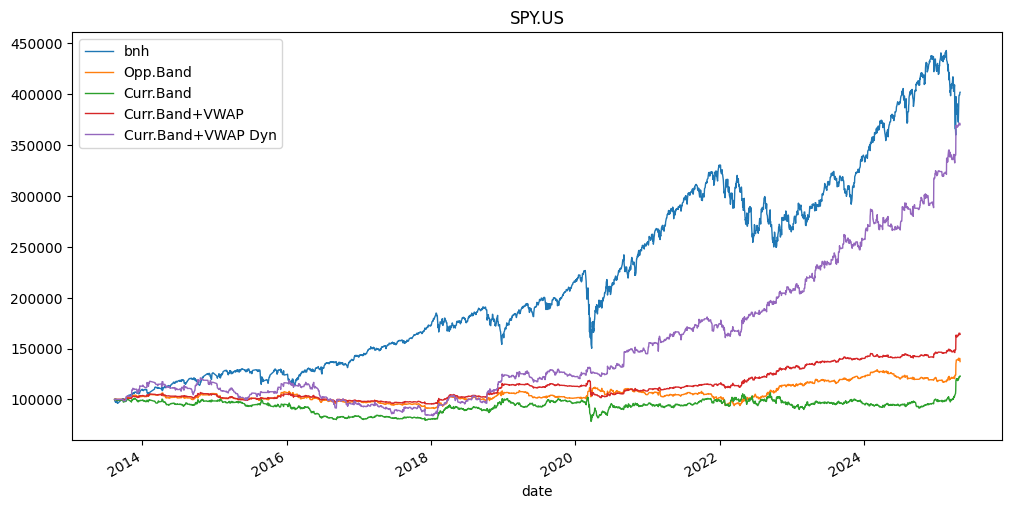

In [22]:
ticker = 'SPY.US'
start_date = dt.date(2013, 8, 13)
end_date = dt.date(2025, 4, 30)

res_spy, res_spy_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=default_config, strategies=strategy_list)
res_spy.plot(linewidth=1, figsize=(12, 6), title=ticker)

<Axes: title={'center': 'IVV.US'}, xlabel='date'>

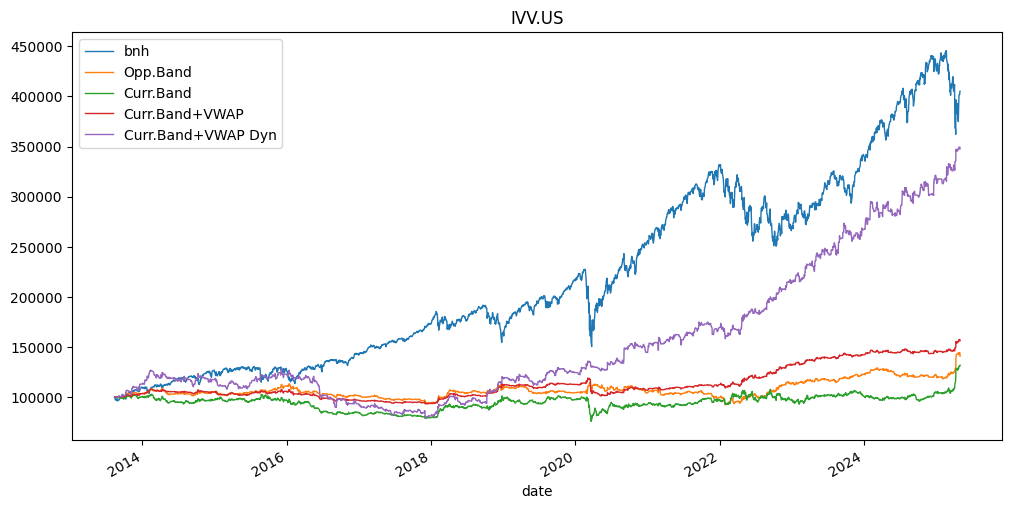

In [23]:
ticker = 'IVV.US'
start_date = res_spy.index.min().date()
end_date = dt.date(2025, 4, 30)

res_ivv, res_ivv_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=default_config, strategies=strategy_list)
res_ivv.plot(linewidth=1, figsize=(12, 6), title=ticker)

In [24]:
cols_to_include = ['bnh', 'Curr.Band+VWAP Dyn']
calc_stats(res_ivv[cols_to_include].join(res_spy[cols_to_include], lsuffix='_IVV', rsuffix='_SPY'), benchmark_col='Curr.Band+VWAP Dyn_SPY')

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_56975/1896129281.py:25: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = res.pct_change().dropna()


Strategy,bnh_IVV,Curr.Band+VWAP Dyn_IVV,bnh_SPY,Curr.Band+VWAP Dyn_SPY
Total Return (%),305.2000,247.7000,302.1000,270.10
Ann. Return (%),12.7000,11.2000,12.6000,11.80
Ann. Volatility (%),17.5000,14.3000,17.4000,14.20
Information Ratio (IR),0.7700,0.8200,0.7700,0.86
Hit Ratio (%),54.7000,43.3000,55.2000,42.70
Max Drawdown (%),33.9000,37.6000,33.7000,30.80
Skewness,-0.3700,1.6700,-0.3100,2.23
Kurtosis,15.1300,12.4500,14.7800,17.91
Alpha vs Curr.Band+VWAP Dyn_SPY (%),14.5100,0.2100,14.3900,NaN
Alpha t-stat,2.8300,0.1400,2.8300,NaN


The above table shows summary statistics of the IVV and SPY strategies. The goal is to show whether the IVV strategy has statistically significant non-zero alpha and statistically significant beta of 1 compared to the SPY strategy. We can see that the the alpha p-value is large, and the beta p-value is very small. This means that the alpha is not statistically significant, but the beta value is 0.94 (close to 1!) is statistically significant. This shows that the IVV strategy is not statistically different from SPY.

### Full Period Backtest

In [25]:
ticker = 'IVV.US'
start_date = dt.date(2007, 1, 1)
end_date = dt.date(2025, 4, 30)


config = StratConfig()
strategy_list = (MomentumOppBand, SimpleTrendStrategy, MomentumVWAP, MomentumVWAPVolScale)

<Axes: title={'center': 'IVV.US'}, xlabel='date'>

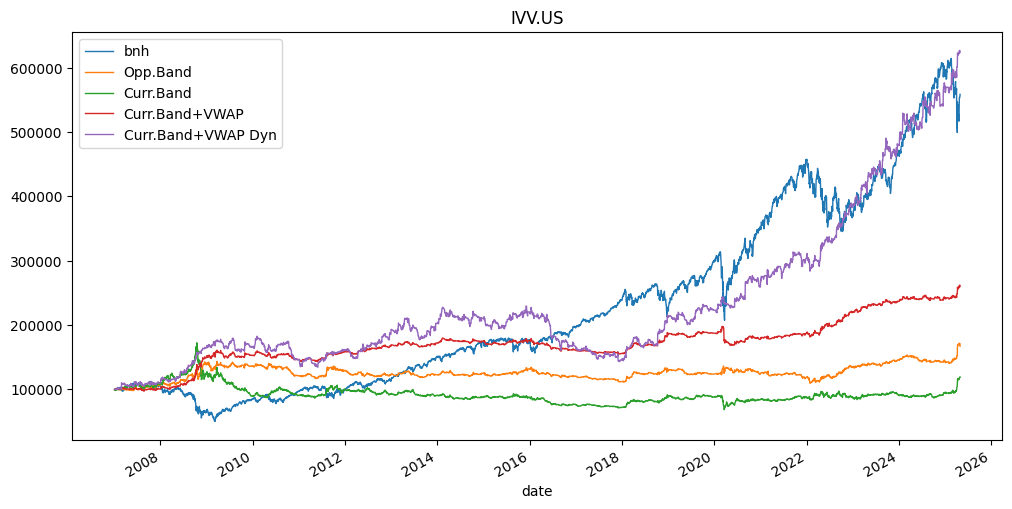

In [26]:
res, res_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config, strategies=strategy_list)
res.plot(linewidth=1, figsize=(12, 6), title=ticker)

In [27]:
stats_df = calc_stats(res)
stats_df

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),458.70,67.2000,19.7000,160.0000,523.9000
Ann. Return (%),9.90,2.8000,1.0000,5.4000,10.5000
Ann. Volatility (%),19.80,10.3000,13.9000,7.5000,14.5000
Information Ratio (IR),0.57,0.3200,0.1400,0.7300,0.7600
Hit Ratio (%),54.70,52.3000,50.7000,42.0000,42.0000
Max Drawdown (%),55.30,23.7000,60.3000,15.0000,37.6000
Skewness,-0.20,0.2100,-0.4600,2.0800,1.8300
Kurtosis,11.50,22.3100,12.2100,21.4300,13.1300
Alpha vs bnh (%),NaN,3.8400,2.0700,6.0300,11.9400
Alpha t-stat,NaN,1.6000,0.6400,3.4500,3.5400


#### Condition Performance on VIX Values

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_56975/1868531000.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vix_cond = df_vix.groupby('VIX_bucket')['ret'].mean() / df_vix.groupby('VIX_bucket')['ret'].std() * np.sqrt(252)


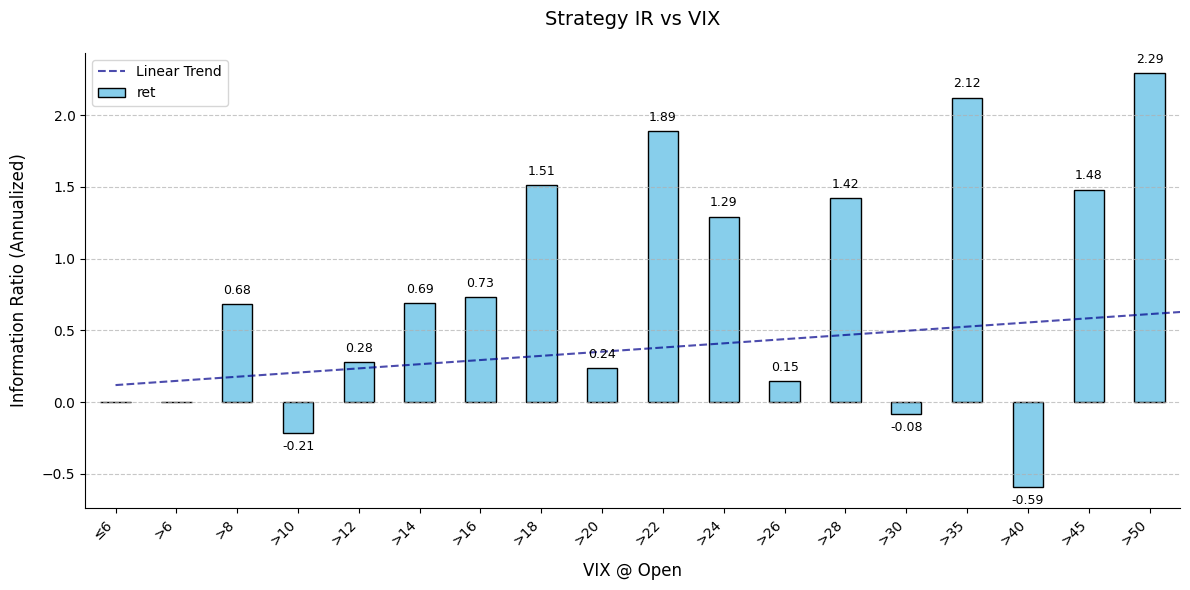

In [28]:
df_vix = pd.read_parquet(f'data/{ticker}.daily.parquet')
df_vix = res.join(df_vix.set_index('date')['VIX'])

# Define the bin edges
bins = [0, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 35, 40, 45, 50, float('inf')]
labels = ['≤6', '>6', '>8', '>10', '>12', '>14', '>16', '>18', 
          '>20', '>22', '>24', '>26', '>28', '>30', '>35', '>40', '>45', '>50']

# Create the bucket column
df_vix['VIX_bucket'] = pd.cut(df_vix['VIX'], bins=bins, labels=labels, right=False)
df_vix['ret'] = df_vix[MomentumVWAPVolScale.name].pct_change()

vix_cond = df_vix.groupby('VIX_bucket')['ret'].mean() / df_vix.groupby('VIX_bucket')['ret'].std() * np.sqrt(252)


# Calculate best fit line using the mid-point of each VIX bucket
bin_midpoints = [(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)]
bin_midpoints[-1] = bins[-2] + 5  # Adjust the last bin's midpoint for better visualization

# Get the IR values
y = vix_cond.fillna(0).values

# Create the plot
plt.figure(figsize=(12, 6))
ax = vix_cond.plot(
    kind='bar', 
    color='skyblue',
    edgecolor='black',
    linewidth=1
)

# Add best fit line using the midpoints of the VIX ranges
x = bins[:-1]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

# Plot the best fit line
plt.plot(x, p(x), 
         '--', 
         color='darkblue', 
         alpha=0.7,
         linewidth=1.5,
         label='Linear Trend')

# Rest of your plot customization
plt.title('Strategy IR vs VIX', fontsize=14, pad=20)
plt.xlabel('VIX @ Open', fontsize=12, labelpad=10)
plt.ylabel('Information Ratio (Annualized)', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['top', 'right']].set_visible(False)

# Add data labels
for i, v in enumerate(vix_cond):
    ax.text(i, v + 0.05 * np.sign(v), 
            f'{v:.2f}', 
            ha='center', 
            va='bottom' if v >= 0 else 'top',
            fontsize=9)

# Add legend
plt.legend()

plt.tight_layout()
plt.show()

#### Condition Performance on Day of Week

In [29]:
df_dow = res.copy()
df_dow['ret'] = df_dow[MomentumVWAPVolScale.name].pct_change().fillna(0)

# Ensure the index is a datetime index and get day of week
df_dow = df_dow.copy()
df_dow.index = pd.to_datetime(df_dow.index)
df_dow = df_dow[df_dow.index.dayofweek < 5]  # Only keep weekdays (0-4 = Mon-Fri)

# Map day of week to day names
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_dow['day_name'] = df_dow.index.dayofweek.map(dict(zip(range(5), day_names)))

from scipy import stats

# Calculate statistics for each day of the week
def calculate_day_stats(day_group):
    returns = day_group['ret']
    n = len(returns)
    mean_bps = returns.mean() * 10000  # Convert to basis points
    t_stat, p_value = stats.ttest_1samp(returns, 0)
    hit_ratio = (returns > 0).mean() * 100  # as percentage
    ir = (returns.mean() / returns.std()) * np.sqrt(252)  # Annualized IR
    
    return pd.Series({
        'N': n,
        'Avg Return (bps)': mean_bps,
        't-stat': t_stat,
        'p-value': p_value,
        'Hit Ratio (%)': hit_ratio,
        'IR': ir
    })

# Apply the function to each day group
results = df_dow.groupby('day_name').apply(calculate_day_stats).loc[day_names]  # Maintain order

# Format the results for display
formatted_results = results.copy()
formatted_results['Avg Return (bps)'] = formatted_results['Avg Return (bps)'].apply(lambda x: f'{x:.2f}')
formatted_results['t-stat'] = formatted_results['t-stat'].apply(lambda x: f'{x:.2f}')
formatted_results['p-value'] = formatted_results['p-value'].apply(lambda x: f'{x:.3f}')
formatted_results['Hit Ratio (%)'] = formatted_results['Hit Ratio (%)'].apply(lambda x: f'{x:.1f}%')
formatted_results['IR'] = formatted_results['IR'].apply(lambda x: f'{x:.2f}')

# Display the table
print("Day of Week Analysis")
print("=" * 80)
print(formatted_results.to_string())
print("\n" + "=" * 80)
print("Note: Returns are in basis points (bps), IR is annualized")

Day of Week Analysis
               N Avg Return (bps) t-stat p-value Hit Ratio (%)    IR
day_name                                                            
Monday     864.0             1.59   0.59   0.555         22.5%  0.32
Tuesday    947.0             3.44   1.18   0.237         25.3%  0.61
Wednesday  946.0             7.39   2.32   0.021         26.2%  1.20
Thursday   930.0             3.82   1.20   0.230         27.3%  0.62
Friday     924.0             5.45   1.83   0.067         25.4%  0.96

Note: Returns are in basis points (bps), IR is annualized


/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_56975/2039035447.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = df_dow.groupby('day_name').apply(calculate_day_stats).loc[day_names]  # Maintain order


#### Results Analysis

Both in the chart and table, we can see that the most advanced version of the strategy, Curr.Band+VWAP Dyn, has the best performance but does not outperform the buy and hold strategy as decidedly as the original paper would propose. With that said, I'd like to propose the following analysis:
- discuss the hypotheses proposed above
- condition results on VIX
- condition results on day of week
- discuss the difference between my results and paper; show examples why I think the paper overestimates the strategy's by having detailed PnL tables
- show my implementation results using open and mid prices for the period to further drive the point of execution assumptions

##### Hypothesis Discussion

The first hypothesis test is existance of simple intraday timeseries momentum via "Noise Area" breaks. There's no statistical evidence for this, as seen by the large p-values for Opp.Band and Curr.Band strategies in the above summary table when regressing the daily returns against the buy and hold strategy.

The next hypothesis is exit engineering via VWAP-aware trailing stop. As seen in the Curr.Band+VWAP column, the t-stat is 3.45 and p-value is 0.0006, which is statistically significant. We can confirm that the strategy indeed produces a non-zero average PnL against the buy and hold.

Looking at the next iteration of the strategy, Curr.Band+VWAP Dyn, we can confirm the hypothesis that volatility targeting produces alpha with low/negative beta. The alpha t-stat is 3.54 with 0.0004 p-value, signifying a statistically significant non-zero alpha value. The beta t-stat is -7.31 with 0.0000 p-value, again signififying confidnce in the beta value of -0.08.

The last hypothesis to test is that profitability increases with volatility. My results are not as convincing as the paper, but there's still a positive slope to the best-fit line if we look at the figure "Strategy IR vs VIX".

##### Direct Comparison Replication to Paper

In [30]:
paper_table3 = pd.DataFrame({
"Opp.Band": {
"Total Return (%)": 178.0, "Ann. Return (%)": 6.2, "Ann. Volatility (%)": 10.9, "Sharpe Ratio": 0.61,
"Hit Ratio (%)": 54.0, "Max Drawdown (%)": 21.0, "Alpha vs BNH (%)": 7.1, "Beta vs BNH": -0.05
},
"Curr.Band+VWAP": {
"Total Return (%)": 380.0, "Ann. Return (%)": 9.7, "Ann. Volatility (%)": 7.7, "Sharpe Ratio": 1.24,
"Hit Ratio (%)": 43.0, "Max Drawdown (%)": 12.0, "Alpha vs BNH (%)": 9.9, "Beta vs BNH": -0.03
},
"Curr.Band+VWAP Dyn": {
"Total Return (%)": 1985.0, "Ann. Return (%)": 19.6, "Ann. Volatility (%)": 14.3, "Sharpe Ratio": 1.33,
"Hit Ratio (%)": 43.0, "Max Drawdown (%)": 25.0, "Alpha vs BNH (%)": 19.6, "Beta vs BNH": -0.07
},
"bnh": {
"Total Return (%)": 227.0, "Ann. Return (%)": 7.2, "Ann. Volatility (%)": 20.2, "Sharpe Ratio": 0.45,
"Hit Ratio (%)": 54.0, "Max Drawdown (%)": 56.0
}
}).T

comparison = paper_table3.join(stats_df.T, lsuffix=" (paper)", rsuffix=" (rep)")
display(comparison.T)

,Opp.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn,bnh
Total Return (%) (paper),178.0000,380.0000,1985.0000,227.00
Ann. Return (%) (paper),6.2000,9.7000,19.6000,7.20
Ann. Volatility (%) (paper),10.9000,7.7000,14.3000,20.20
Sharpe Ratio,0.6100,1.2400,1.3300,0.45
Hit Ratio (%) (paper),54.0000,43.0000,43.0000,54.00
Max Drawdown (%) (paper),21.0000,12.0000,25.0000,56.00
Alpha vs BNH (%),7.1000,9.9000,19.6000,NaN
Beta vs BNH,-0.0500,-0.0300,-0.0700,NaN
Total Return (%) (rep),67.2000,160.0000,523.9000,458.70
Ann. Return (%) (rep),2.8000,5.4000,10.5000,9.90


The above table pulls in results directly from the paper. It's pretty clear that the results in the paper are much better performance wise (both absolute returns and return/risk ratio). I have some theories on this that I will discuss below. I am lucky that the code used in the paper is actually posted online.

#### Original Paper Results

I copied this code directly from the link in the paper: https://concretumgroup.com/python-backtesting-beat-the-market-an-effective-intraday-momentum-strategy-for-the-sp500-etf-spy/. The only changes I made are compatibility with my data and additional logging to examine a potential lookahead bias.

#### Intraday Debug
Helpful to have a zoomed in chart to visualize the trade patterns.

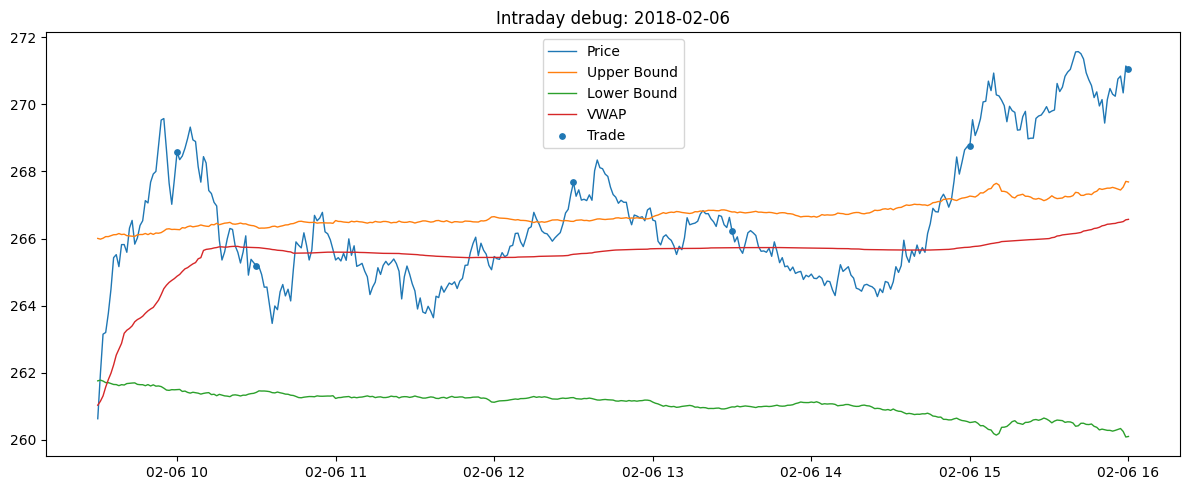

In [31]:
plot_day_debug(res_details['Curr.Band+VWAP Dyn'], dt.date(2018, 2, 6), price_col="close", ub_col="noise_upper", lb_col="noise_lower", vwap_col="vwap", exposure_col="signal", ts_col="datetime")

In [32]:
paper_strat, paper_debug = paper_logic(ticker=ticker, sd=start_date, ed=end_date)

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_56975/2842247581.py:179: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp.loc[:, 'exposure'] = exposure
/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_56975/2842247581.py:180: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp.loc[:, 'LB'] = lb_shift
/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_56975/2842247581.py:181: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc

In [33]:
calc_stats(paper_strat[['AUM', 'bnh']])

Strategy,AUM,bnh
Total Return (%),1160.80,452.50
Ann. Return (%),14.90,9.80
Ann. Volatility (%),15.00,19.80
Information Ratio (IR),1.00,0.57
Hit Ratio (%),42.80,54.70
Max Drawdown (%),33.10,55.30
Skewness,1.74,-0.20
Kurtosis,13.45,11.51
Alpha vs bnh (%),15.94,NaN
Alpha t-stat,4.57,NaN


Again, the strategy trades every 30min (let's call it T). It uses the bar data from the previous observation(T-1). My expectations would be that for the time period when the trade is entered, T, the PnL **should not** be from T-1 close to T close. The below table shows an example. Showing specific time-stamps where a trade was entered and there's a non-zero PnL on the minute the trade was executed. The PnL is equivalent to the difference of the previous minute's close and the minute when trade is executed. This is not realistic. So the paper results are collecting a PnL that you would not realize in real life. The next few cells show such examples.

In [34]:
paper_debug[(paper_debug.time >= dt.time(14, 58)) & (paper_debug.time <= dt.time(15, 2))]

,time,close,vwap,exposure,LB,UB,sigma,trade,price_change,shares,gross_pnl
1074628,14:58:00,268.64,265.734567,0.0,260.576589,267.203320,0.005020,False,0.37,0.0,0.00
1074629,14:59:00,268.74,265.737082,0.0,260.565492,267.214586,0.005090,False,0.10,0.0,0.00
1074630,15:00:00,268.77,265.743044,1.0,260.546904,267.233457,0.005207,True,0.03,2469.0,74.07
1074631,15:01:00,269.54,265.757120,1.0,260.516467,267.264360,0.005164,False,0.77,2469.0,1901.13
1074632,15:02:00,269.07,265.766129,1.0,260.527638,267.253018,0.005103,False,-0.47,2469.0,-1160.43


In [35]:
# calculate the PnL by hand
2469 * (268.77 - 268.74)

74.06999999993263

In [36]:
# another example of the same thing - PnL at 12:30
paper_debug[(paper_debug.time >= dt.time(12, 28)) & (paper_debug.time <= dt.time(12, 32))]

,time,close,vwap,exposure,LB,UB,sigma,trade,price_change,shares,gross_pnl
1074478,12:28:00,266.8700,265.495155,0.0,261.234941,266.534912,0.002434,False,0.1100,0.0,0.0000
1074479,12:29:00,267.3190,265.517104,0.0,261.242455,266.527283,0.002379,False,0.4490,0.0,0.0000
1074480,12:30:00,267.6723,265.529922,1.0,261.257008,266.512508,0.002369,True,0.3533,2469.0,872.2977
1074481,12:31:00,267.2600,265.535543,1.0,261.259520,266.509957,0.002494,False,-0.4123,2469.0,-1017.9687
1074482,12:32:00,267.4500,265.545314,1.0,261.226863,266.543113,0.002511,False,0.1900,2469.0,469.1100


In [37]:
# again - calculate by hand
2469 * (267.6723 - 267.3190)

872.2976999999757

My conclusion is that the paper has lookahead bias. In my backtest I am assuming that the execution price is the close price on T. Perhaps that is too conservative. Below I run my implementation of the backtest, but assuming that I am executing my trades using the open price of the period.

#### Backtest Results using the Open as Execution Price
This is trying to mimic the paper closer by using the open price as the execution price. We can see that the results for the strategy are much better, and are closer to the original paper. This is still not a realistic execution point.

<Axes: title={'center': 'IVV.US'}, xlabel='date'>

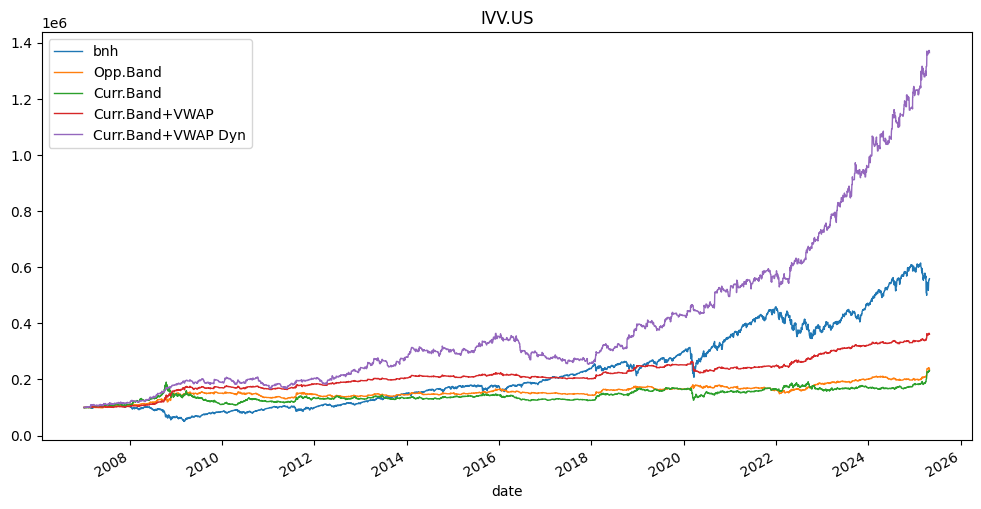

In [38]:
config_open = StratConfig(execution_price='open')
res_open, res_open_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config_open, strategies=strategy_list)
res_open.plot(linewidth=1, figsize=(12, 6), title=ticker)

In [39]:
calc_stats(res_open)

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),458.70,134.9000,132.0000,260.90,1264.20
Ann. Return (%),9.90,4.8000,4.7000,7.30,15.40
Ann. Volatility (%),19.80,10.4000,13.9000,7.60,14.60
Information Ratio (IR),0.57,0.5000,0.4000,0.96,1.05
Hit Ratio (%),54.70,52.8000,51.3000,42.50,42.50
Max Drawdown (%),55.30,17.8000,43.0000,15.40,30.20
Skewness,-0.20,0.1800,-0.2300,1.91,1.83
Kurtosis,11.50,22.4400,10.1900,20.58,11.84
Alpha vs bnh (%),NaN,5.6700,5.6700,7.77,16.23
Alpha t-stat,NaN,2.3400,1.7500,4.38,4.77


#### Backtest Results using the Mid as Execution Price
Next, let's try using the mid price `(ask-bid)/2`. We can see that the results are slightly better than buy and hold. This further shows how quickly the signal decays. For a retail trader, which is kind of the target audience of this paper, this is a very important detail. The trader needs to have a live market feed and be very aware of his quickly the trade logic runs. Additionally, how do you set the execution price when submitting the order? Sure, you could submit a market order but you are leaving much to chance. This is perhaps a further research question: when submitting a trade in this strategy, how to set the correct price for your limit order? If the price is moving up (down), it could be the T-1 close price with some multiplier applied. The multiplier could be data mined using the previous periods of your backtest. 

<Axes: title={'center': 'IVV.US'}, xlabel='date'>

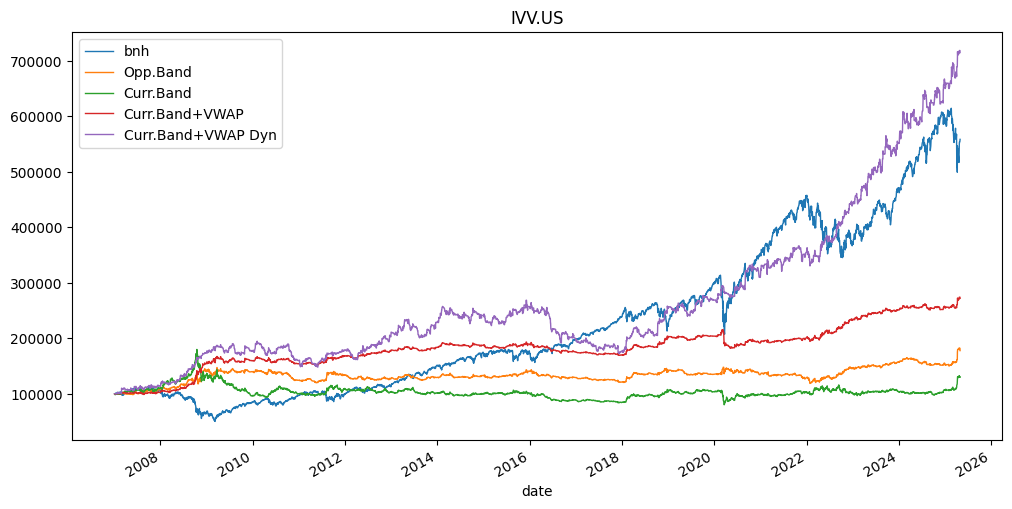

In [40]:
config_open = StratConfig(execution_price='mid')
res_open, res_open_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config_open, strategies=strategy_list)
res_open.plot(linewidth=1, figsize=(12, 6), title=ticker)

In [41]:
calc_stats(res_open)

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),458.70,77.9000,31.0000,172.1000,615.2000
Ann. Return (%),9.90,3.2000,1.5000,5.6000,11.4000
Ann. Volatility (%),19.80,10.3000,13.8000,7.5000,14.4000
Information Ratio (IR),0.57,0.3600,0.1800,0.7600,0.8200
Hit Ratio (%),54.70,52.0000,50.5000,41.7000,41.7000
Max Drawdown (%),55.30,19.7000,55.4000,15.5000,35.6000
Skewness,-0.20,0.1900,-0.3200,2.0100,1.8000
Kurtosis,11.50,22.0600,10.8700,20.8600,12.2100
Alpha vs bnh (%),NaN,4.1500,2.5500,6.2600,12.6700
Alpha t-stat,NaN,1.7300,0.7900,3.5800,3.7700


### Extending the Research

#### Recent Time

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),15.10,15.300,14.8000,3.1000,-2.4000
Ann. Return (%),21.90,22.200,21.4000,4.4000,-3.3000
Ann. Volatility (%),20.80,12.400,13.9000,6.6000,11.5000
Information Ratio (IR),1.06,1.680,1.4700,0.6900,-0.2400
Hit Ratio (%),57.50,56.500,56.4000,45.7000,45.7000
Max Drawdown (%),18.80,4.400,10.2000,4.8000,11.6000
Skewness,1.13,7.220,2.3000,3.7800,1.3100
Kurtosis,17.58,79.460,16.9400,25.5700,13.8600
Alpha vs bnh (%),NaN,16.200,18.3400,3.6500,-3.7000
Alpha t-stat,NaN,1.170,1.1200,0.4700,-0.2700


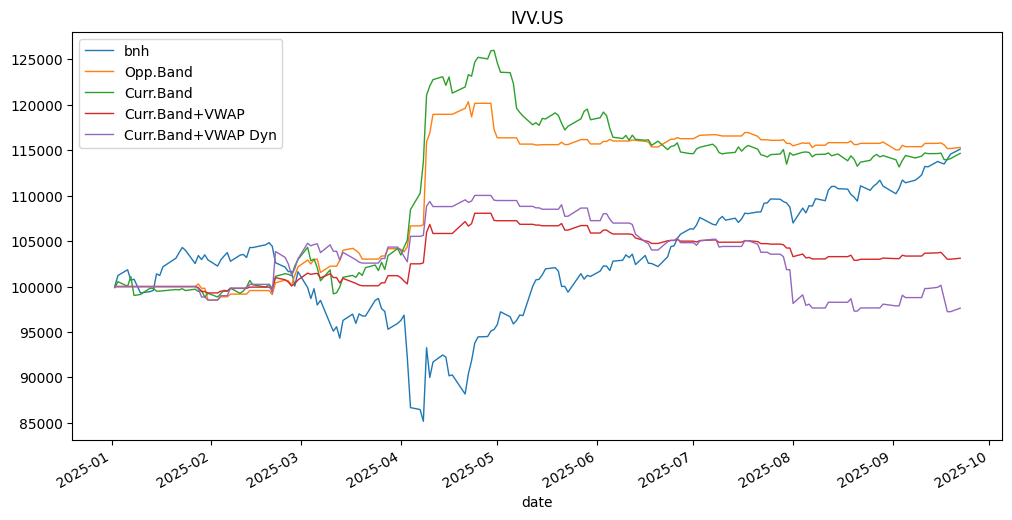

In [42]:
ticker = 'IVV.US'
start_date = dt.date(2025, 1, 1)
end_date = dt.date(2026, 1, 1)


config = StratConfig()
strategy_list = (MomentumOppBand, SimpleTrendStrategy, MomentumVWAP, MomentumVWAPVolScale)

res, res_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config, strategies=strategy_list)
res.plot(linewidth=1, figsize=(12, 6), title=ticker)

stats_df = calc_stats(res)
stats_df

During more recent time period, specifically 2025, the strategy underperforms buy and hold. 

#### Additional Instruments

##### IWM: Small-cap US ETF

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),302.40,-13.9000,65.3000,-29.4000,-35.5000
Ann. Return (%),7.70,-0.8000,2.7000,-1.8000,-2.3000
Ann. Volatility (%),24.90,13.1000,17.5000,9.6000,14.8000
Information Ratio (IR),0.42,0.0000,0.2400,-0.1400,-0.0900
Hit Ratio (%),53.40,51.3000,52.3000,40.0000,40.0000
Max Drawdown (%),59.00,57.5000,55.5000,54.8000,60.1000
Skewness,-0.33,-0.7100,-0.0600,1.4200,1.1100
Kurtosis,6.18,15.8400,5.6700,16.2000,9.9700
Alpha vs bnh (%),NaN,0.7100,4.5300,-1.0300,-0.8900
Alpha t-stat,NaN,0.2300,1.1200,-0.4600,-0.2600


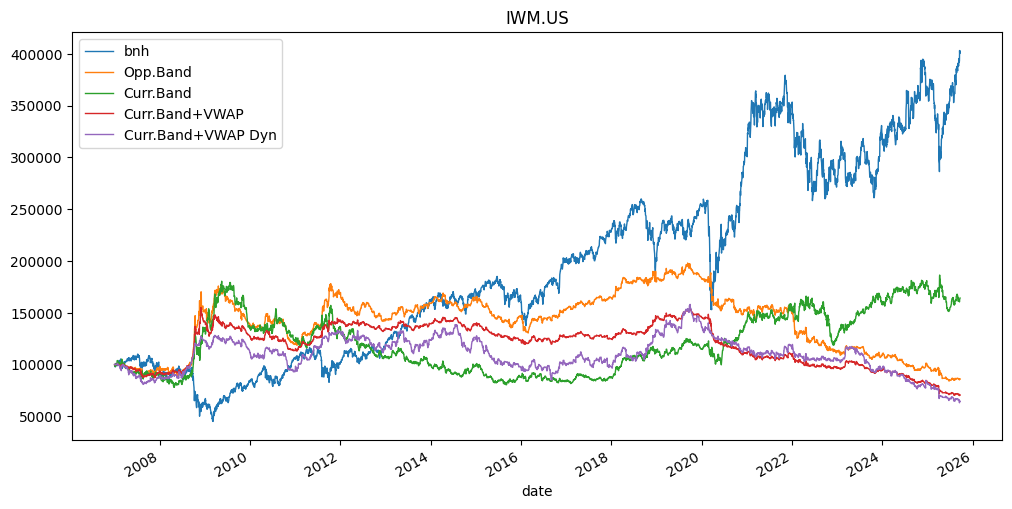

In [43]:
ticker = 'IWM.US'
start_date = dt.date(2007, 1, 1)
end_date = dt.date(2026, 1, 1)


config = StratConfig()
strategy_list = (MomentumOppBand, SimpleTrendStrategy, MomentumVWAP, MomentumVWAPVolScale)

res, res_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config, strategies=strategy_list)
stats_df = calc_stats(res)

res.plot(linewidth=1, figsize=(12, 6), title=ticker)
stats_df

##### QQQ: Tech-focused ETF

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),1129.70,155.4000,33.3000,176.7000,475.1000
Ann. Return (%),18.90,6.7000,2.0000,7.3000,12.9000
Ann. Volatility (%),20.90,10.1000,14.4000,7.8000,14.1000
Information Ratio (IR),0.94,0.6900,0.2100,0.9400,0.9300
Hit Ratio (%),56.00,53.6000,50.3000,43.5000,43.5000
Max Drawdown (%),35.10,24.3000,43.3000,14.2000,27.7000
Skewness,-0.21,1.0100,-0.2200,2.2500,1.8100
Kurtosis,7.61,26.1400,12.6100,35.0600,12.0800
Alpha vs bnh (%),NaN,7.0000,2.5900,7.4800,13.8300
Alpha t-stat,NaN,2.6400,0.6800,3.6500,3.7300


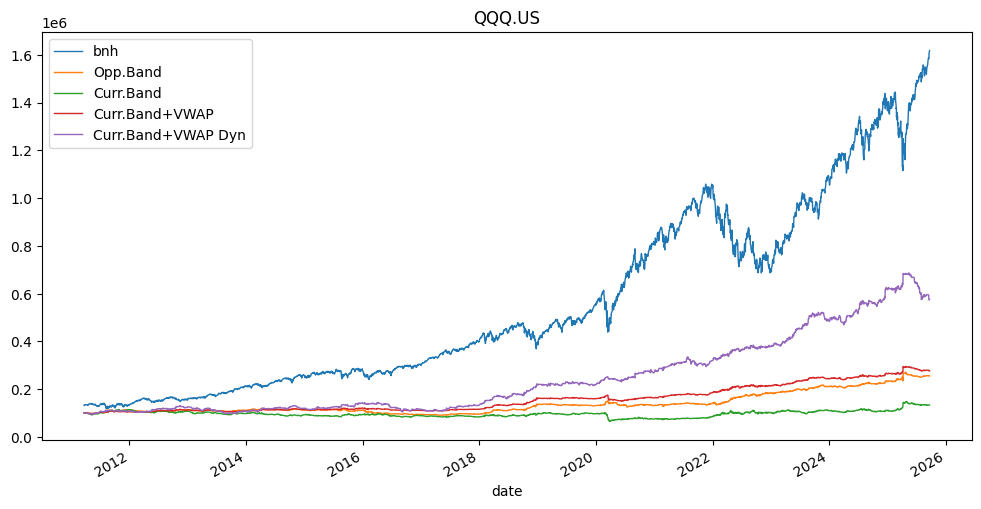

In [44]:
ticker = 'QQQ.US'
start_date = dt.date(2007, 1, 1)
end_date = dt.date(2026, 1, 1)


config = StratConfig()
strategy_list = (MomentumOppBand, SimpleTrendStrategy, MomentumVWAP, MomentumVWAPVolScale)

res, res_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config, strategies=strategy_list)
stats_df = calc_stats(res)

res.plot(linewidth=1, figsize=(12, 6), title=ticker)
stats_df

##### GLD: Gold ETF

Strategy,bnh,Opp.Band,Curr.Band,Curr.Band+VWAP,Curr.Band+VWAP Dyn
Total Return (%),454.00,-15.9000,-60.5000,-10.6000,-25.1000
Ann. Return (%),9.60,-0.9000,-4.8000,-0.6000,-1.5000
Ann. Volatility (%),17.40,7.7000,10.6000,6.0000,11.7000
Information Ratio (IR),0.61,-0.0800,-0.4200,-0.0700,-0.0700
Hit Ratio (%),53.00,46.3000,48.4000,37.2000,37.2000
Max Drawdown (%),45.60,37.9000,67.7000,24.9000,55.4000
Skewness,-0.11,-0.6100,0.7900,3.8000,2.8300
Kurtosis,6.33,86.0900,11.7900,83.6900,25.7900
Alpha vs bnh (%),NaN,-0.6500,-4.4800,-0.5600,-1.0200
Alpha t-stat,NaN,-0.3600,-1.8200,-0.4000,-0.3800


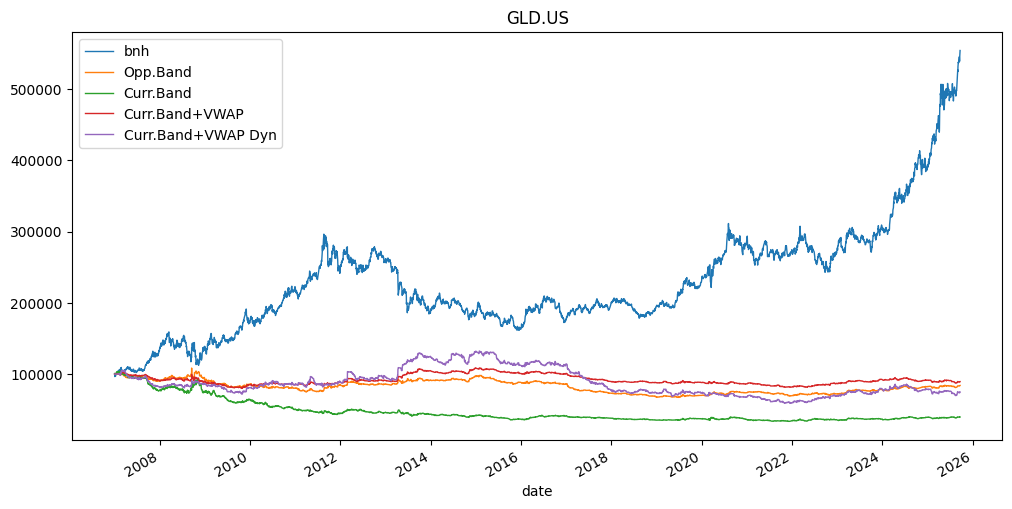

In [45]:
ticker = 'GLD.US'
start_date = dt.date(2007, 1, 1)
end_date = dt.date(2026, 1, 1)


config = StratConfig()
strategy_list = (MomentumOppBand, SimpleTrendStrategy, MomentumVWAP, MomentumVWAPVolScale)

res, res_details = run_strategy_comparison(ticker=ticker, start_date=start_date, end_date=end_date, config=config, strategies=strategy_list)
stats_df = calc_stats(res)

res.plot(linewidth=1, figsize=(12, 6), title=ticker)
stats_df

### Future Research
- as mentioned before, execution is paramount for this strategies success, so an additional set of research should be performed on setting the execution price.
- Different momentum signals (MACD, RSI, etc) could be evalulated
- the different parematers for calculating the noise band as well as volatility of underlying could be tuned.
- Apply additional vol scaling using VIX values.
- Faster trading: shorten the trade interval from 30min.